In [11]:
import pandas as pd
from preprocessing import preprocess_all
from models import (fit_rw_with_drift, forecast_rw_with_drift,
                    fit_arima_model, forecast_arima_model, select_var_lag, fit_var_model, forecast_var_model, align_lagged_with_train_test, rf_time_series_cv)
from sklearn.ensemble import RandomForestRegressor


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

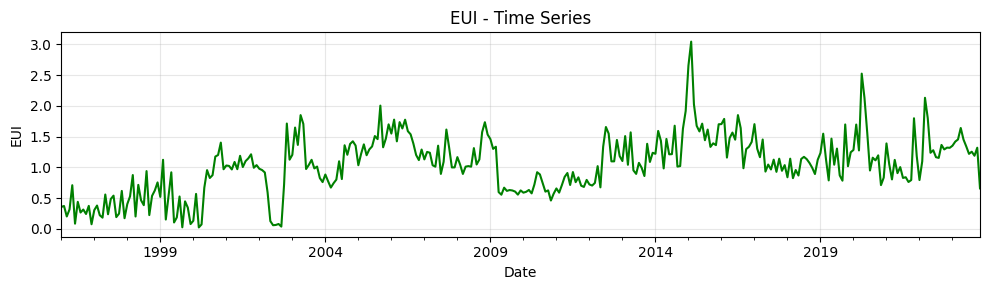

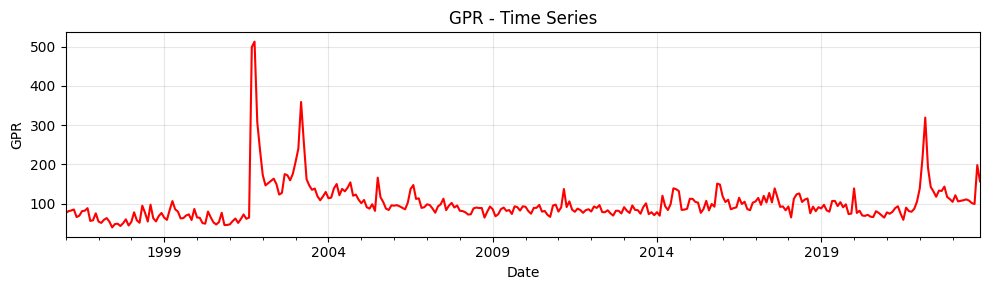

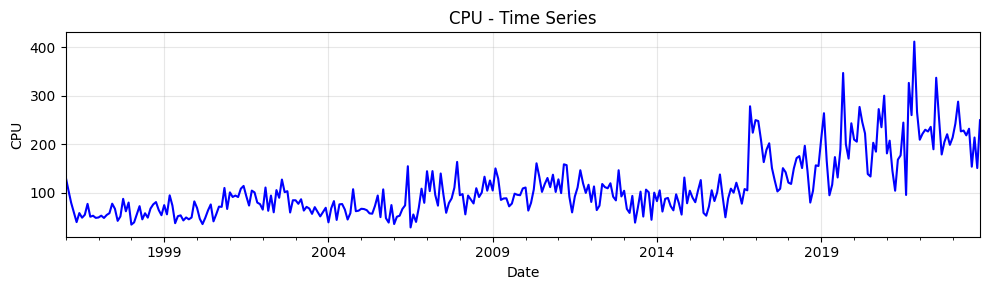

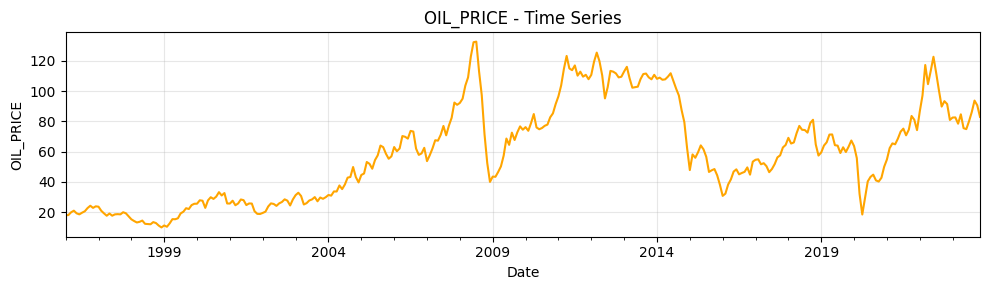

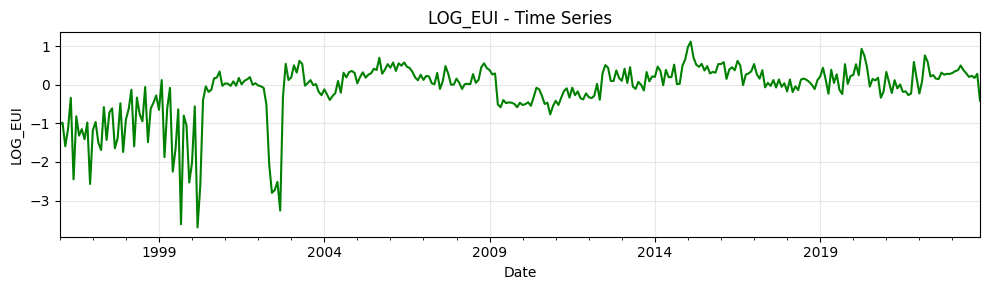

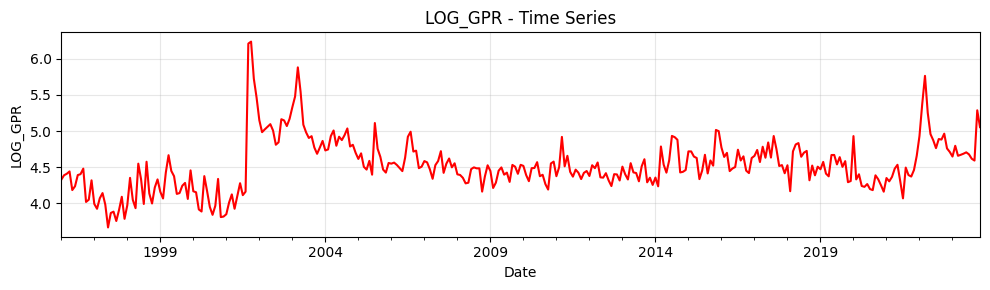

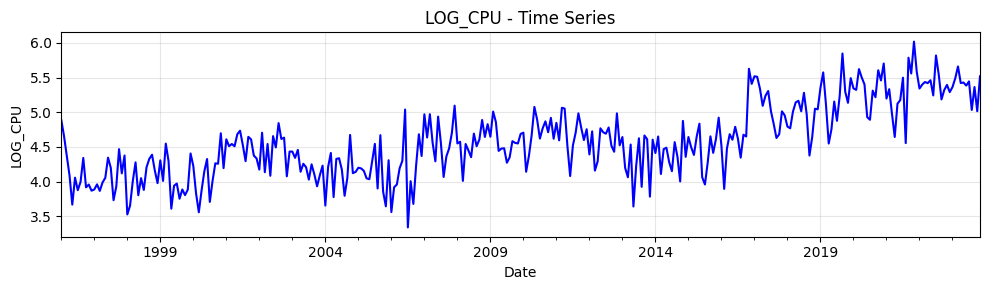

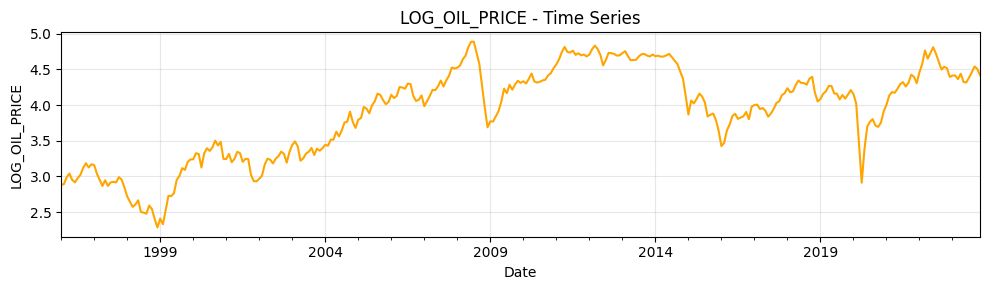

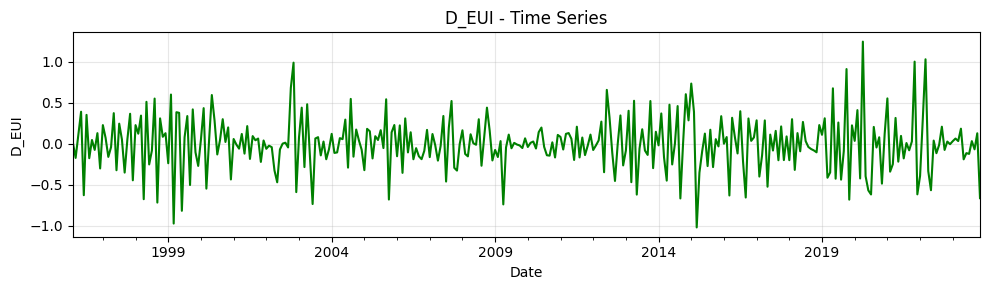

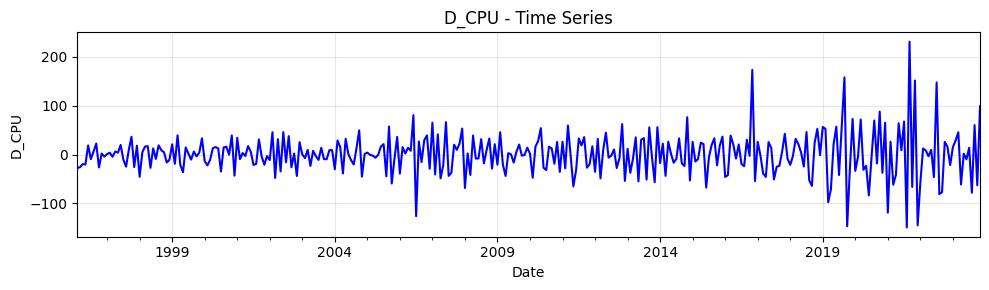

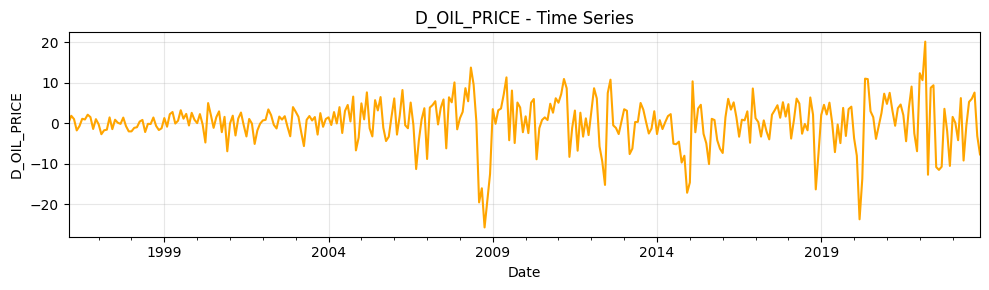

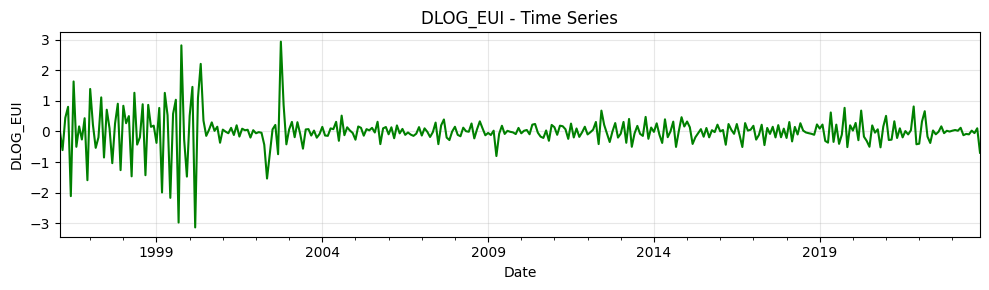

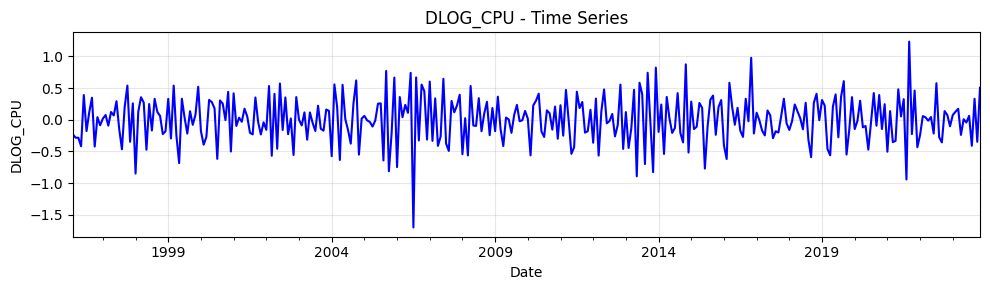

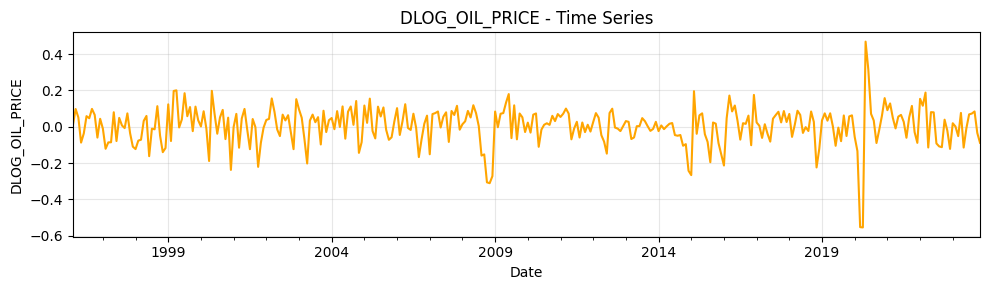

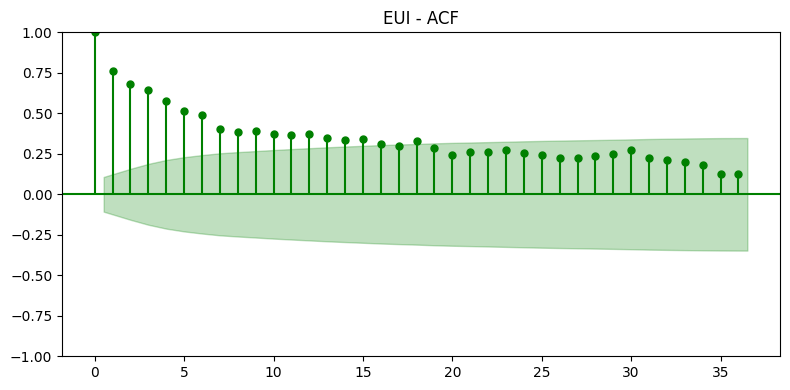

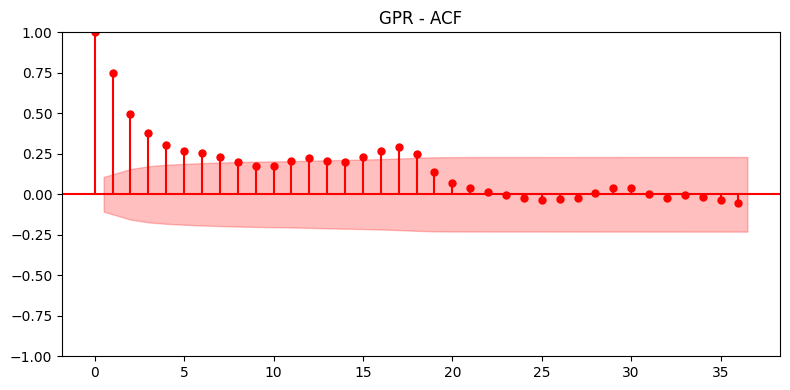

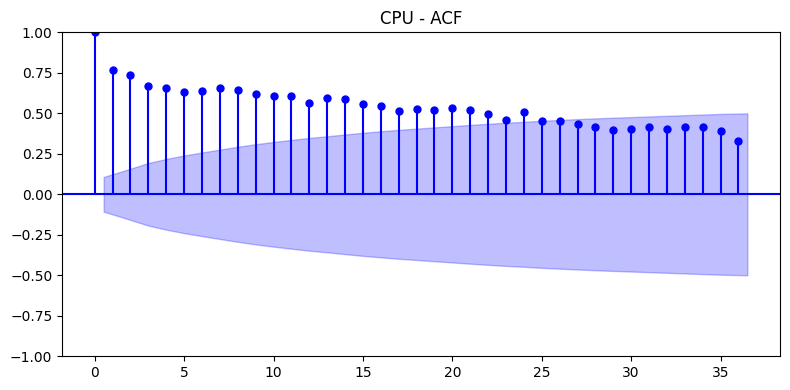

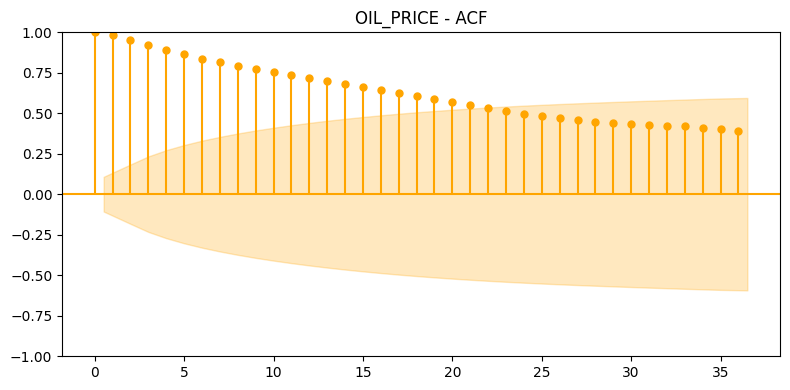

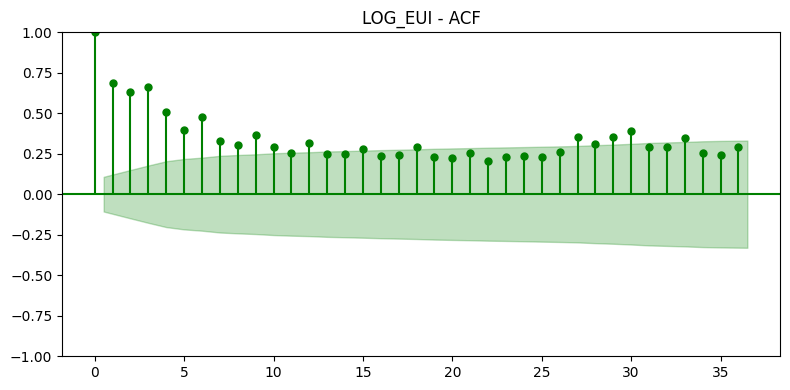

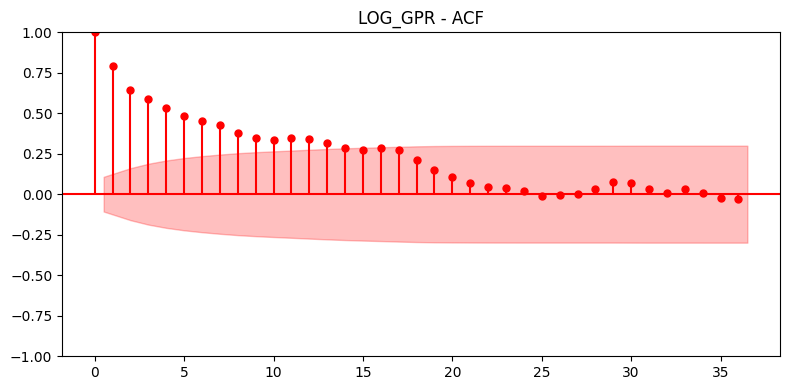

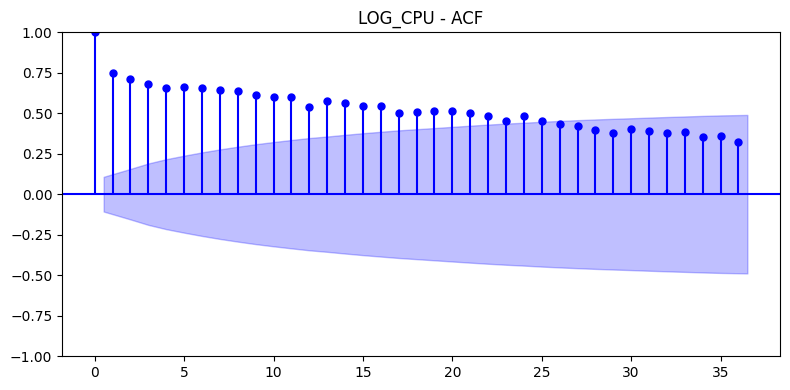

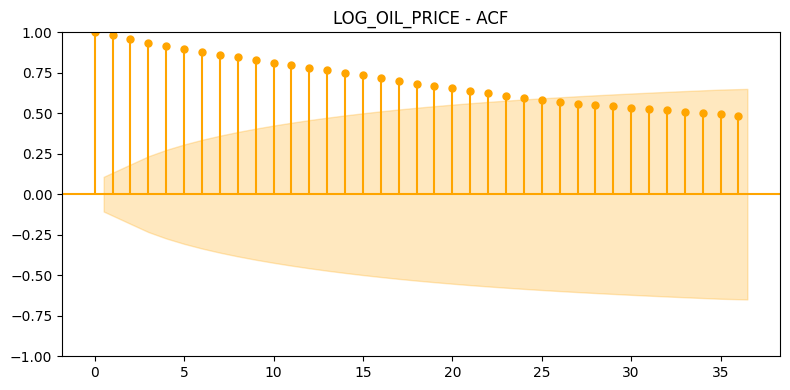

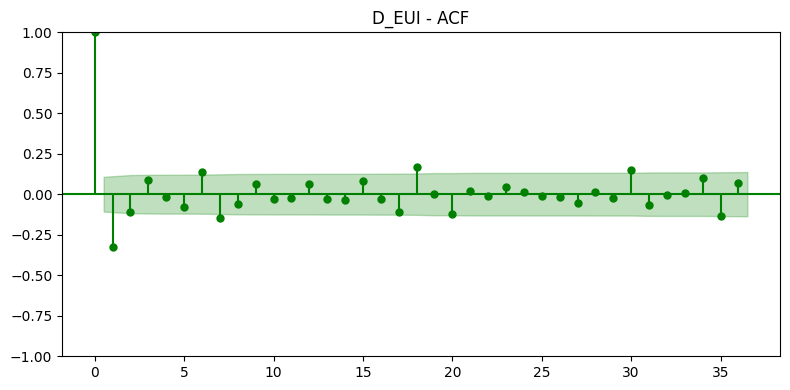

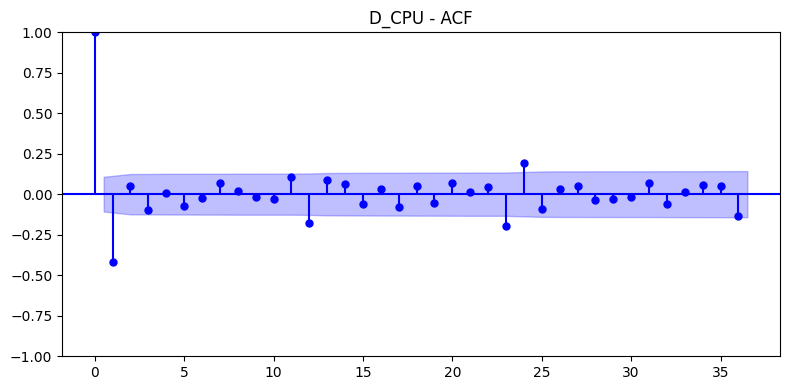

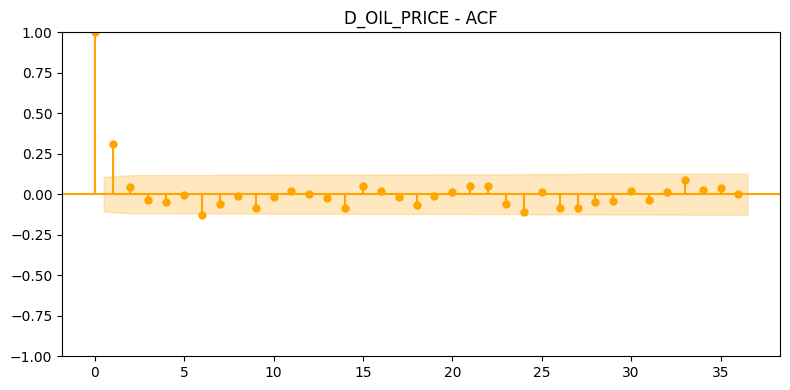

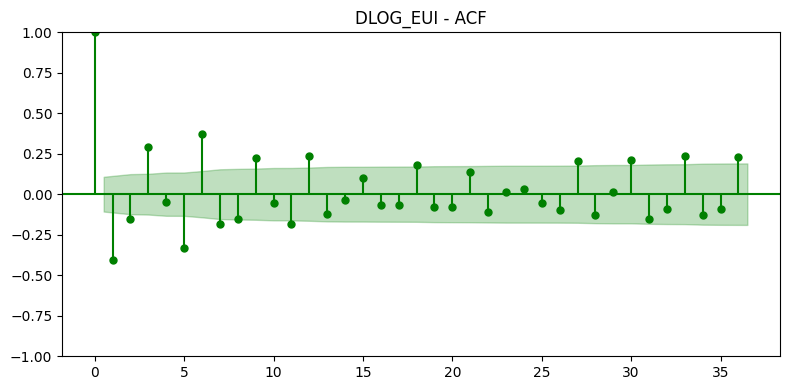

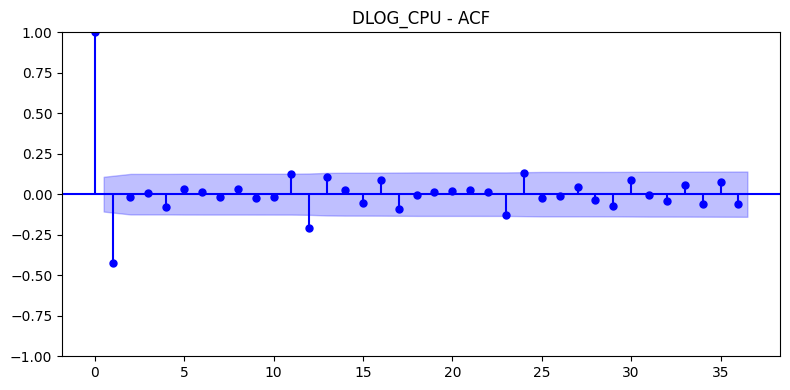

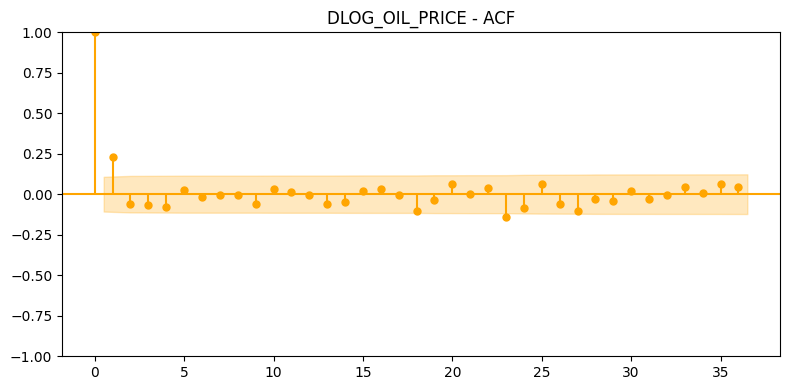

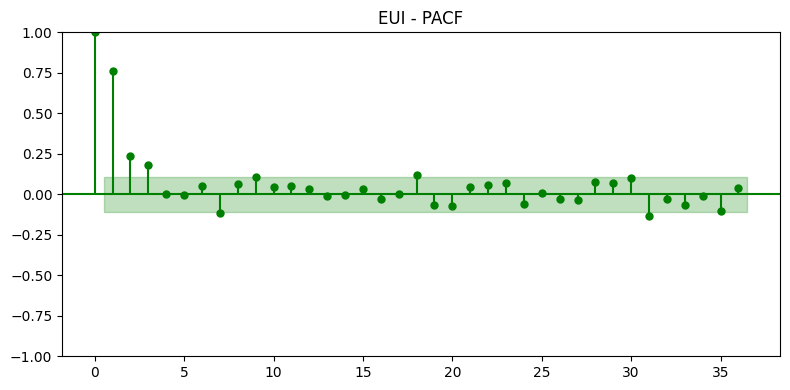

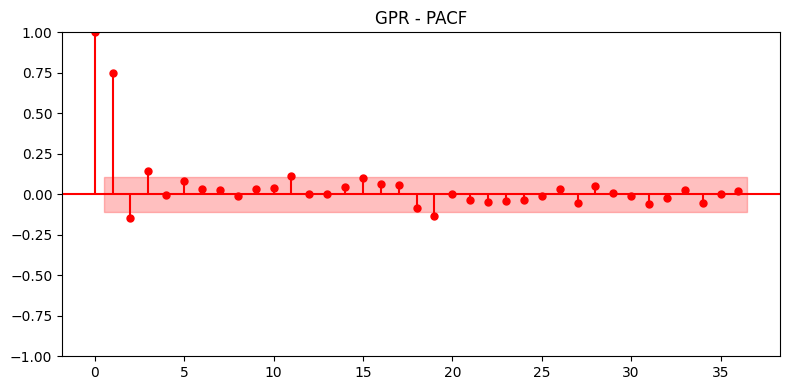

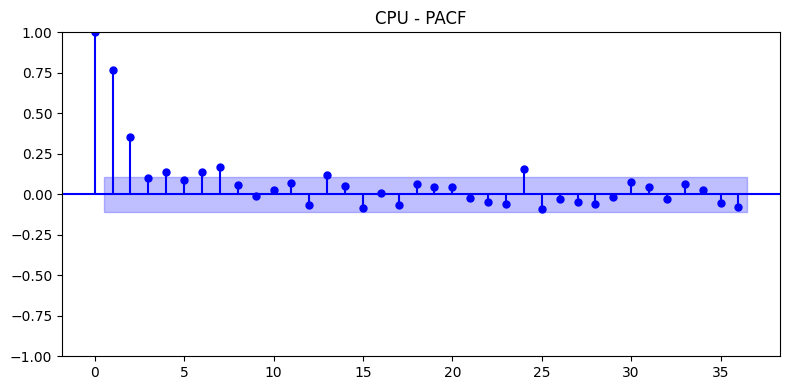

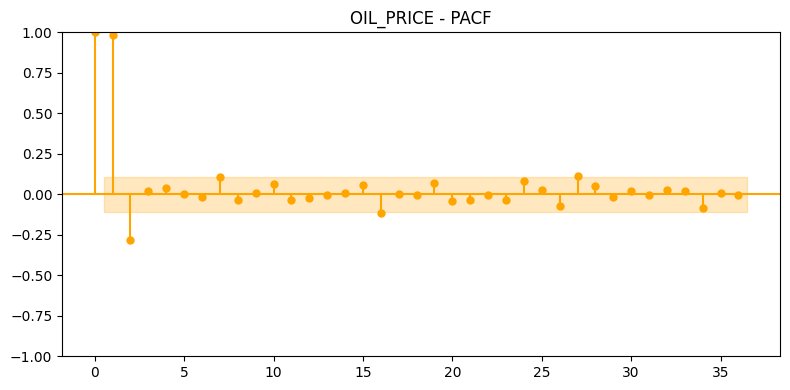

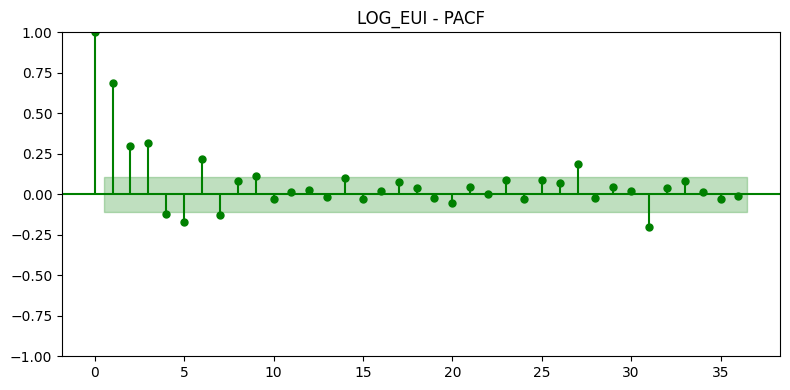

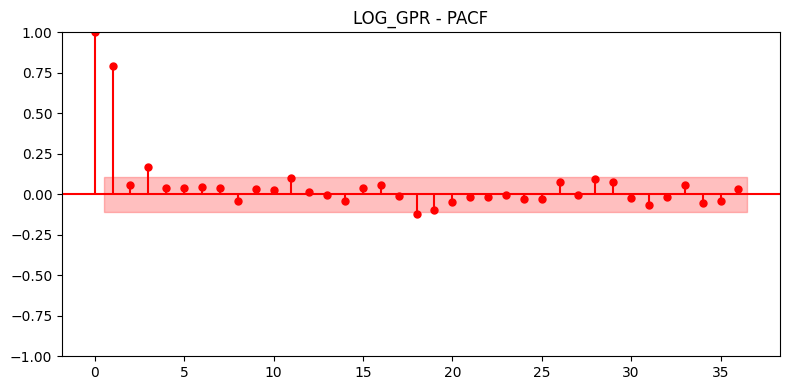

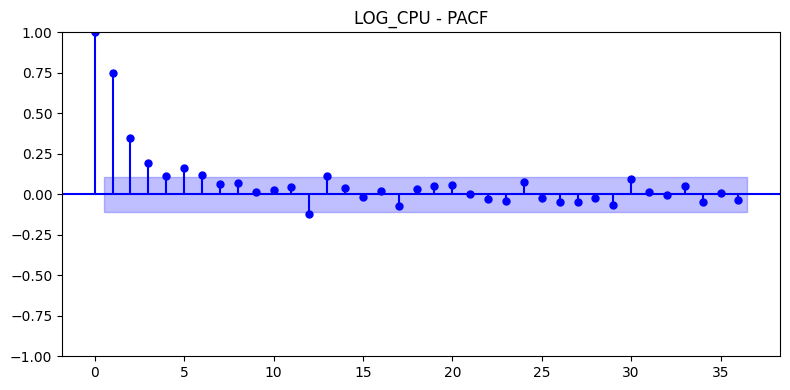

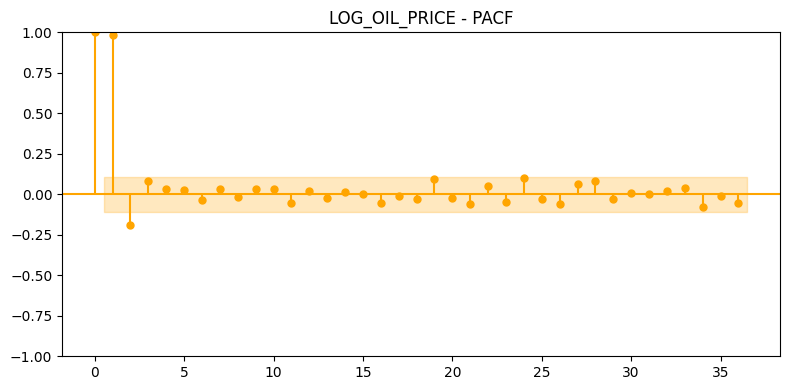

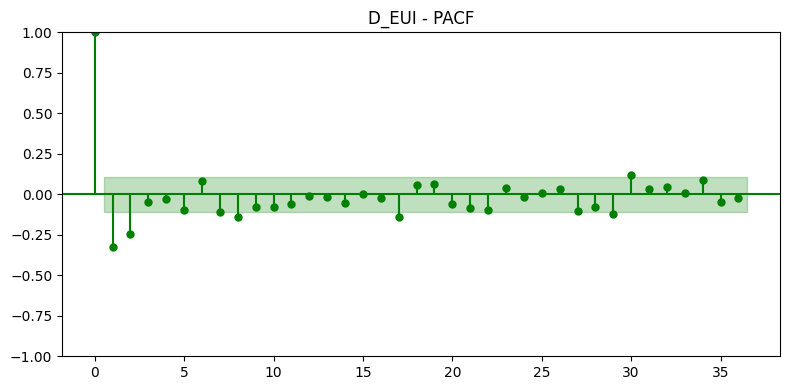

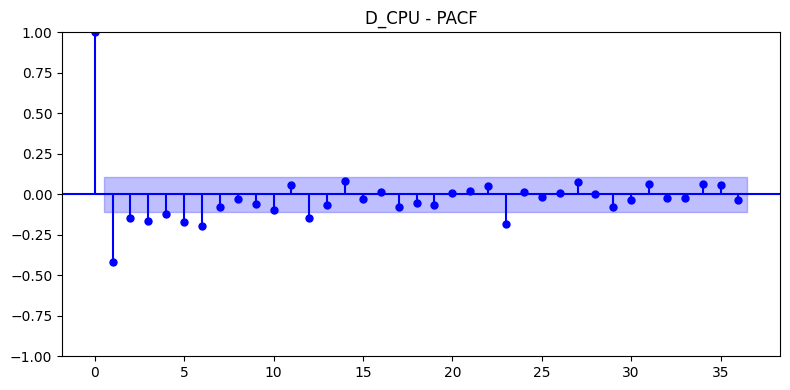

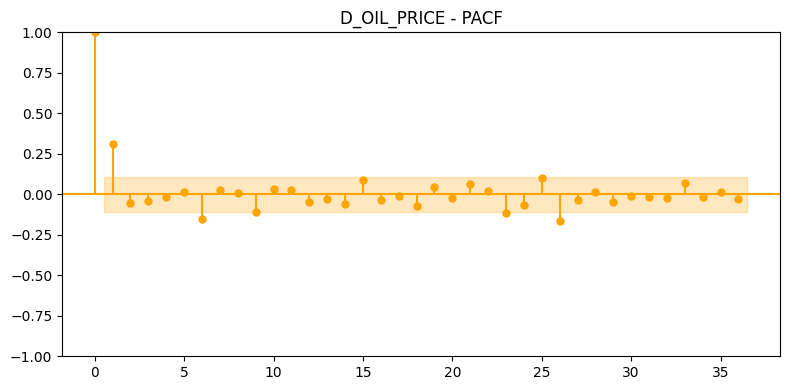

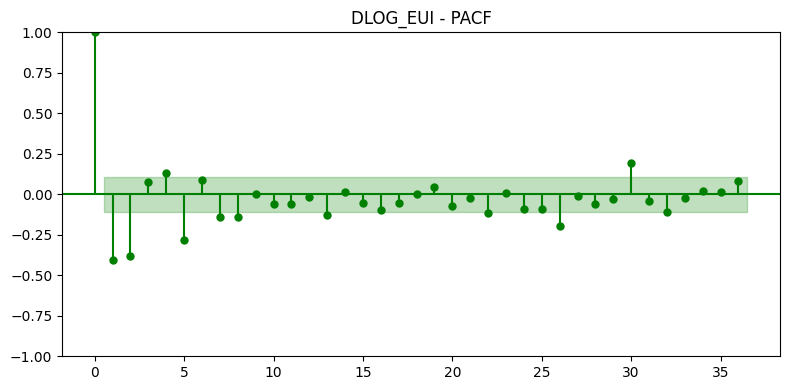

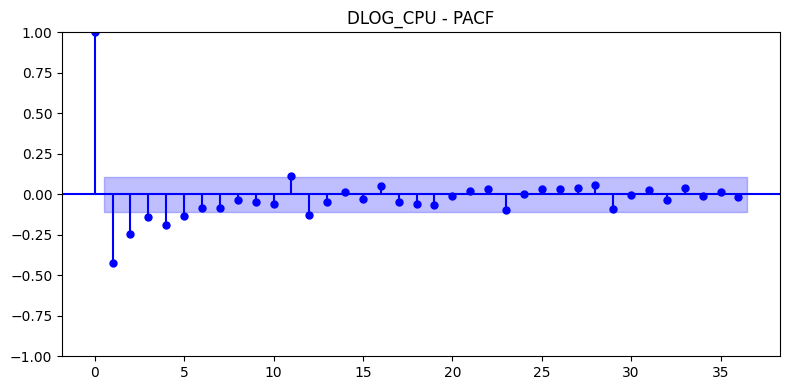

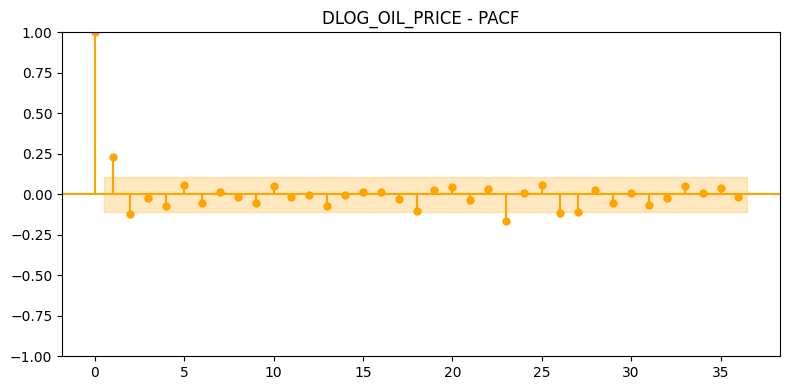

In [12]:
artifacts = preprocess_all(
    data_path="data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags={
        "variables": ("eui", "gpr", "cpu", "oil_price", "log_eui", "log_gpr", "log_cpu",
                      "log_oil_price", "d_eui", "d_cpu", "d_oil_price", "dlog_eui",
                      "dlog_cpu", "dlog_oil_price",
        ),
        "lags": 36,
        "time_series": True,
        "acf": True,
        "pacf": True,
        "pacf_method": "ywm",
    },
)

In [13]:
# ---------------------------------------------------
# 0. Preprocess and get train/test
# ---------------------------------------------------

train_df = artifacts["train_df"]
test_df = artifacts["test_df"]
features_df = artifacts["features_df"]

target_col = "eui"   # or "log_eui", "dlog_eui", etc. depending on your choice

In [14]:
# ---------------------------------------------------
# 1. Random Walk with Drift
# ---------------------------------------------------
rw_fit = fit_rw_with_drift(train_df[target_col])
rw_fcast = forecast_rw_with_drift(
    rw_fit,
    steps=len(test_df),
    index=test_df.index,
)

In [20]:
# ---------------------------------------------------
# 2. ARIMA
# (choose order & seasonal_order based on ACF/PACF & theory)
# ---------------------------------------------------

orders_to_try = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (0, 1, 1),
    (2, 1, 0),
]

seasonal_order = (0, 0, 0, 0)  # if no seasonality
y_train = train_df[target_col]
y_test  = test_df[target_col]

results_dict = {}
forecasts_dict = {}
errors_dict = {}

for order in orders_to_try:
    print(f"\n=== Fitting ARIMA{order} ===")

    # Fit deterministic ARIMA
    res = fit_arima_model(
        y=y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    # Save model results (optional)
    results_dict[order] = res

    # Forecast for test sample length
    fcast = forecast_arima_model(
        res=res,
        steps=len(y_test),
        index=y_test.index
    )
    forecasts_dict[order] = fcast

    # Compute forecast errors
    errors = y_test - fcast
    errors_dict[order] = errors

    print(res.summary())


=== Fitting ARIMA(1, 1, 1) ===
                               SARIMAX Results                                
Dep. Variable:                    eui   No. Observations:                  268
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -39.806
Date:                Thu, 13 Nov 2025   AIC                             85.613
Time:                        18:13:07   BIC                             96.352
Sample:                    01-01-1996   HQIC                            89.927
                         - 04-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0843      0.117      0.718      0.473      -0.146       0.314
ma.L1         -0.5021      0.099     -5.061      0.000      -0.696      -0.308
sigma2         0.079

In [22]:
# ---------------------------------------------------------------------
# 3. VAR: multivariate dynamics of (dlog_eui, log_gpr, dlog_cpu, dlog_oil_price)
# ---------------------------------------------------------------------
var_cols = ["dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]

best_lag, order_sel = select_var_lag(
    df=train_df,
    endog_cols=var_cols,
    maxlags=6,
    ic="bic",
    date_col="date",
)

print("Selected VAR lag (BIC):", best_lag)
print(order_sel.summary())  # shows table like in the slides

# Fit VAR with chosen lag
var_res = fit_var_model(
    df=train_df,
    endog_cols=var_cols,
    maxlags=best_lag,
    ic=None,        # we already chose lag ourselves
    date_col="date",
    trend="c",
)

# Forecast over the test horizon
var_fcast_df = forecast_var_model(
    res=var_res,
    steps=len(test_df),
    index=test_df.index,
)

var_dlog_eui_fcast = var_fcast_df["dlog_eui"]


Selected VAR lag (BIC): 1
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -9.743      -9.688   5.873e-05      -9.721
1      -11.09     -10.82*   1.521e-05      -10.98
2      -11.26      -10.77   1.282e-05     -11.07*
3      -11.27      -10.56   1.274e-05      -10.99
4      -11.31      -10.38   1.223e-05      -10.94
5     -11.38*      -10.23  1.149e-05*      -10.91
6      -11.34      -9.977   1.189e-05      -10.79
-------------------------------------------------


In [23]:
# ---------------------------------------------------
# 4. Random Forest with lagged predictors
# ---------------------------------------------------
rf_feature_cols = ["gpr", "cpu", "oil_price", "COVID_WINDOW_2020_03_11_2023_05_05", "RU_UA_WAR_PULSE_2022_02_24", "FUKUSHIMA_PULSE_2011_03_11", "GFC_WINDOW_2007_12_01_2009_06_30", "PARIS_COP21_PULSE_2015_12_12", "SEP11_PULSE_2001_09_11"]

X_train, y_train, X_test, y_test = align_lagged_with_train_test(
    features_df=features_df,
    train_df=train_df,
    test_df=test_df,
    target_col=target_col,
    feature_cols=rf_feature_cols,
    max_lag=12,
    date_col="date",
)

param_grid = [
    {"n_estimators": 300, "max_depth": 3, "min_samples_leaf": 1},
]

best_params, rf_cv_results = rf_time_series_cv(
    X=X_train,
    y=y_train,
    param_grid=param_grid,
    initial_train_size=int(len(y_train) * 0.5),  # first 50% as initial training
    h=1,
    step=1,
    random_state=42,
)

print("Best RF params:", best_params)
print(rf_cv_results)

# Fit final RF on full training set with best params
rf_best = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    **best_params,
)
rf_best.fit(X_train, y_train)

rf_fcast = rf_best.predict(X_test)
rf_fcast_series = pd.Series(rf_fcast, index=X_test.index, name="rf_forecast")


Best RF params: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 1}
                                              params      msfe
0  {'n_estimators': 300, 'max_depth': 3, 'min_sam...  0.092999
